# Событийная аналитика + анализ результатов A/A/B теста: кейс мобильного приложения

Описание:  
Я работаю в стартапе по продаже продуктов питания. Нужно разобраться в поведении пользователей мобильного приложения. После этого проанализировать результаты A/A/B-эксперимента. Дизайнеры захотели поменять шрифты во всём приложении, а менеджеры испугались, что пользователям будет непривычно. Договорились принять решение по результатам A/A/B-теста. Пользователи разбиты на 3 группы: 2 контрольные (старый шрифт) и 1 экспериментальная (новый шрифт)

Задачи:
1. Анализ воронки продаж:
- Как пользователи доходят до покупки?
- Сколько доходит, а сколько отваливается?
- На каких шагах основные проблемы?

2. Анализ результатов A/A/B-теста:
- Проверить корректность сегментации пользователей.
- Сравнить результаты контрольных групп с экспериментальной  
- Определить, какой шрифт лучше

Описание данных (Каждая запись в логе — это действие пользователя, или событие):
- EventName — название события;
- DeviceIDHash — уникальный идентификатор пользователя;
- EventTimestamp — время события;
- ExpId — номер эксперимента: 246 и 247 — контрольные группы, а 248 — экспериментальная.


## Считывание данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from scipy import stats as st
import numpy as np
import plotly.express as px
import math as mth

In [2]:
data = pd.read_csv("data/logs_exp.csv", sep='\t')
data.head()

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


Из полученных данных пропусков не видно и типы данных выглядят корректно

## Изучение и предобработка данных

### Смена названия столбцов и удаление дубликатов

In [4]:
data.columns =  ['event_name', 'user_id', 'event_timestamp', 'group']
data.head()

,event_name,user_id,event_timestamp,group
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [5]:
data.duplicated().sum() / data.shape[0]

np.float64(0.0016917493425526163)

Дубликаты составляют меньше 0.2%, удаляем их

In [6]:
data = data.drop_duplicates().reset_index(drop=True)
data.duplicated().sum()

np.int64(0)

### Добавление отдельных столбцов даты и даты и времени

In [7]:
data['datetime'] = pd.to_datetime(data['event_timestamp'], unit='s')
data['date'] = data['datetime'].dt.date
data = data.drop('event_timestamp', axis=1)
data

,event_name,user_id,group,datetime,date
0,MainScreenAppear,4575588528974610257,246,2019-07-25 04:43:36,2019-07-25
1,MainScreenAppear,7416695313311560658,246,2019-07-25 11:11:42,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,248,2019-07-25 11:28:47,2019-07-25
3,CartScreenAppear,3518123091307005509,248,2019-07-25 11:28:47,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,248,2019-07-25 11:48:42,2019-07-25
...,...,...,...,...,...
243708,MainScreenAppear,4599628364049201812,247,2019-08-07 21:12:25,2019-08-07
243709,MainScreenAppear,5849806612437486590,246,2019-08-07 21:13:59,2019-08-07
243710,MainScreenAppear,5746969938801999050,246,2019-08-07 21:14:43,2019-08-07
243711,MainScreenAppear,5746969938801999050,246,2019-08-07 21:14:58,2019-08-07


In [8]:
row_count_first = data.shape[0]
print(f"Количество строк: {row_count_first}")

users_count_first = data['user_id'].nunique()
print(f"Количество пользователей: {users_count_first}")

Количество строк: 243713
Количество пользователей: 7551


У нас 7551 уникальный пользователей, давайте посмотрим сколько действий делает каждый пользователь в среднем и есть ли аномалии

In [9]:
round(data.groupby('user_id').count()['event_name'].describe(), 2)

count    7551.00
mean       32.28
std        65.15
min         1.00
25%         9.00
50%        20.00
75%        37.00
max      2307.00
Name: event_name, dtype: float64

Среднее количество событий на пользователя составляет примерно 32, однако видно что максимальнок количество составляет 2307, слишком большой перепед относительно среднего, рассмотрим данные подробнее

In [10]:
np.percentile(data.groupby('user_id').count()['event_name'], [95, 99])

array([ 89. , 200.5])

Видно что ниже 200.5 находится 99 процентов значений, уберем значениния больше 1000, чтоб не терялось слишьком много данных.

In [11]:
user_id = data.groupby('user_id', as_index=False).agg({'event_name':'count'})
filtered_user_id = user_id.loc[user_id['event_name'] < 1000]
data = data.loc[data['user_id'].isin(filtered_user_id['user_id'])]

round(data.groupby('user_id').count()['event_name'].describe(), 2)

count    7545.00
mean       30.99
std        44.98
min         1.00
25%         9.00
50%        20.00
75%        37.00
max       888.00
Name: event_name, dtype: float64

In [12]:
row_count_second = data.shape[0]
print(f"Количество строк после удаления аномалий: {row_count_second}")
users_count_second = data['user_id'].nunique()
print(f"Количество пользователей после удаления аномалий: {users_count_second}")

Количество строк после удаления аномалий: 233794
Количество пользователей после удаления аномалий: 7545


In [13]:
print(round(row_count_second/row_count_first, 3), round(users_count_second/users_count_first, 3))

0.959 0.999


Удалены пользователи с аномально высоким количеством событий (более 1000).  
Данный порог выше 99-го перцентиля, однако выбран компромиссно, чтобы не терять значительную часть данных.  
В результате было удалено около 4% записей и 0,1% пользователей, что минимально влияет на выборку, но позволяет избавиться от сильных выбросов.  

In [14]:
print(data['date'].min(), data['date'].max())

2019-07-25 2019-08-07


Наши данные описываю промежуток времени с 25.07.2019 по 07.08.2019, представим распределение данных о количестве событий по датам для наглядности

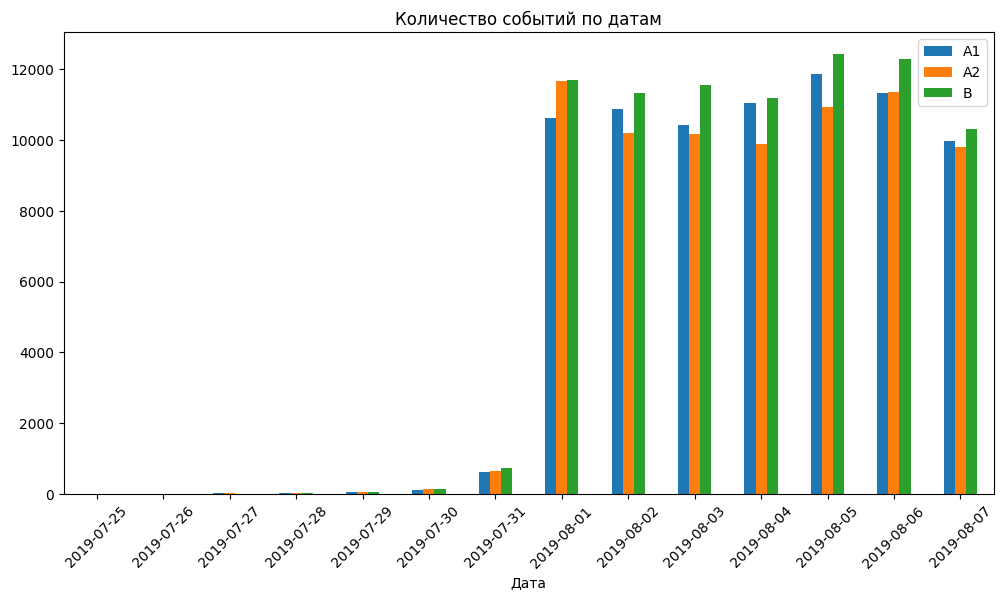

In [15]:
data.pivot_table(index='date', values='user_id', columns='group', aggfunc='count').plot.bar(figsize=(12,6))

plt.xticks(rotation=45)
plt.title('Количество событий по датам')
plt.ylabel('')
plt.xlabel('Дата')
plt.legend(['A1', 'A2', 'B'])
plt.show()

Из графика явно виден рост количества событий после 01.08.2019. Возьмем данные начиная с 01.08.2019, чтобы избежать перекос количества событий по датам

In [16]:
data = data.query('date >= datetime.date(2019,8,1)')

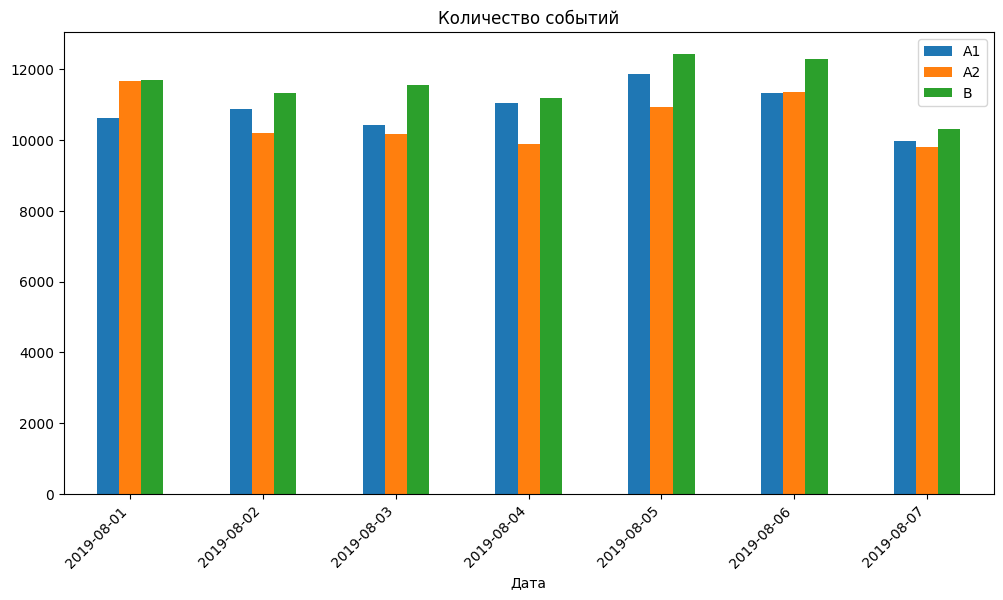

In [17]:
data.pivot_table(index='date', values='user_id', columns='group', aggfunc='count').plot.bar(figsize=(12,6))

plt.xticks(rotation=45, ha='right')
plt.title('Количество событий')
plt.xlabel('Дата')
plt.ylabel('')
plt.legend(['A1', 'A2', 'B'])
plt.show()

In [18]:
row_count_third = data.shape[0]
print(f"Количество строк после удаления аномалий: {row_count_third}")

users_count_third = data['user_id'].nunique()
print(f"Количество строк после удаления аномалий: {users_count_third}")

Количество строк после удаления аномалий: 230970
Количество строк после удаления аномалий: 7528


In [19]:
print(round(row_count_third/row_count_first, 3), round(users_count_third/users_count_first, 3))

0.948 0.997


После того как мы отбросили данные по датам, у нас получилось, что всего мы отбросили ~5% записей, и ~0,3% пользователей

In [20]:
round(data.groupby('user_id').count()['event_name'].describe(), 2)

count    7528.00
mean       30.68
std        44.84
min         1.00
25%         9.00
50%        19.00
75%        37.00
max       888.00
Name: event_name, dtype: float64

После обработки данных мы получаем такой итог:
- Всего в логе 230970 событий и 7528 уникальных пользователей. В среднем на пользователя приходится 30.7 события.
- Полные данные имеются за период 01.08-07.08, до 01.08 данные сократили, так как они не полные

## Изучение воронки событий

In [21]:
data['event_name'].value_counts()

event_name
MainScreenAppear           116919
OffersScreenAppear          45382
CartScreenAppear            37954
PaymentScreenSuccessful     29710
Tutorial                     1005
Name: count, dtype: int64

In [22]:
users_events = data.groupby('event_name')['user_id'].nunique().sort_values(ascending=False)
users_events

event_name
MainScreenAppear           7413
OffersScreenAppear         4587
CartScreenAppear           3728
PaymentScreenSuccessful    3533
Tutorial                    840
Name: user_id, dtype: int64

Мы получили количество уникальных пользователей которые доходят до определенного этапа, посмотрим в долевом соотношении с общим количеством уникальных пользователей

In [23]:
round(users_events / data['user_id'].nunique(), 3)

event_name
MainScreenAppear           0.985
OffersScreenAppear         0.609
CartScreenAppear           0.495
PaymentScreenSuccessful    0.469
Tutorial                   0.112
Name: user_id, dtype: float64

Из полученных данных, можно логично построить последовательность шагов:
1) Главная страница
2) Карточка предложения/товара
3) Корзина
4) Успешная оплата
5) Обучение (Можно выделить как необязательную категорю отдельно от остальных, поскольку у него крйне низкая доходимость. Возможно не все пользователи им пользуются)



In [24]:
round(users_events / users_events.shift(1), 3)

event_name
MainScreenAppear             NaN
OffersScreenAppear         0.619
CartScreenAppear           0.813
PaymentScreenSuccessful    0.948
Tutorial                   0.238
Name: user_id, dtype: float64

In [25]:
fig = px.funnel(users_events[:4], x=users_events[:4].values, y = users_events[:4].index)
fig.update_layout(yaxis_title=None)
fig.show()

Из проведенного анализа видно, что больше всего пользователей отпадает именно на этапе обучения, однако если его не брать в учет, то самое больше подение по колчиеству пользователей будет на этапе просмотра предложений, что очень близко к реалиям.  

In [26]:
round(users_events.iloc[-2] / users_events.iloc[0], 3)

np.float64(0.477)

От первого события до оплаты доходит 47,7% пользователей.

## Изучение результатов A/A/B эксперимента

In [27]:
data.groupby('group').nunique()['user_id']

group
246    2482
247    2511
248    2535
Name: user_id, dtype: int64

In [28]:
alpha = 0.05 
events_names = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful', 'Tutorial']
p_values = []

def get_pvalue(events_names, group_first, group_second):
    if not isinstance(group_first, list):
        group_first = [group_first]
    if not isinstance(group_second, list):
        group_second = [group_second]
        
    group_all = group_first + group_second
    
    # Посчитаем количество пользователей в группах
    users_per_group = (
        data[data['group'].isin(group_all)]
        .groupby('group')['user_id']
        .nunique()
    )
    
    # Считаем пользователей совершивших событие
    for event in events_names:
        print(f"\nСобытие: {event}")
        
        event_users = (
            data[(data['event_name'] == event) & (data['group'].isin(group_all))]
            .groupby('group')['user_id']
            .nunique()
        )
        
        print('Количество пользователей по группам:')
        print(event_users)
        
        
        successes = []
        trials = []
    
        for group in [group_first, group_second]:
            group_users = sum(users_per_group[g] for g in group)
            group_seccess = sum(event_users.get(g, 0) for g in group)
        
            trials.append(group_users)
            successes.append(group_seccess)
        
        successes = np.array(successes)
        trials = np.array(trials)
    
        # Посчитаем доли
    
        p1 = successes[0] / trials[0]
        p2 = successes[1] / trials[1]
    
        print(f'Доля пользователей совершивших целевое действие в первой группе: {round(p1, 4)}')
        print(f'Доля пользователей совершивших целевое действие во второй группе: {round(p2, 4)}')
    
        # z-test
        p_combined = successes.sum() / trials.sum()
        difference = p1 - p2
    
        z_value = difference / mth.sqrt(
            p_combined * (1 - p_combined) * (1 / trials[0] + 1 / trials[1])
        )
    
        p_value = (1  - st.norm.cdf(abs(z_value))) * 2 # Так как тест двусторонний
    
        p_values.append([group_first, group_second, event, p_value])
    
        print('p-value:', round(p_value, 4))
    
        if p_value < alpha:
            print('Есть статистически значимая разница, отверагем H0')
        else:
            print('Статитстически значимой разницы не обнаружено, не получилось отвергуть H0')

In [29]:
get_pvalue(events_names, 246, 247)


Событие: MainScreenAppear
Количество пользователей по группам:
group
246    2448
247    2474
Name: user_id, dtype: int64
Доля пользователей совершивших целевое действие в первой группе: 0.9863
Доля пользователей совершивших целевое действие во второй группе: 0.9853
p-value: 0.7571
Статитстически значимой разницы не обнаружено, не получилось отвергуть H0

Событие: OffersScreenAppear
Количество пользователей по группам:
group
246    1540
247    1518
Name: user_id, dtype: int64
Доля пользователей совершивших целевое действие в первой группе: 0.6205
Доля пользователей совершивших целевое действие во второй группе: 0.6045
p-value: 0.2481
Статитстически значимой разницы не обнаружено, не получилось отвергуть H0

Событие: CartScreenAppear
Количество пользователей по группам:
group
246    1264
247    1236
Name: user_id, dtype: int64
Доля пользователей совершивших целевое действие в первой группе: 0.5093
Доля пользователей совершивших целевое действие во второй группе: 0.4922
p-value: 0.2288
С

Поскольку статистической разницы обнаружено не было, нет оснований считать что разбиение на группы работает не корректно 

**Сравнение показателей групп A1 и B**

- H0 (нулевая гипотеза): доля пользователей, совершивших событие, одинакова в группах A1 и B.
- H1 (альтернативная гипотеза): доля пользователей, совершивших событие, различается между группами A1 и B.

In [30]:
get_pvalue(events_names, 246, 248)


Событие: MainScreenAppear
Количество пользователей по группам:
group
246    2448
248    2491
Name: user_id, dtype: int64
Доля пользователей совершивших целевое действие в первой группе: 0.9863
Доля пользователей совершивших целевое действие во второй группе: 0.9826
p-value: 0.295
Статитстически значимой разницы не обнаружено, не получилось отвергуть H0

Событие: OffersScreenAppear
Количество пользователей по группам:
group
246    1540
248    1529
Name: user_id, dtype: int64
Доля пользователей совершивших целевое действие в первой группе: 0.6205
Доля пользователей совершивших целевое действие во второй группе: 0.6032
p-value: 0.2084
Статитстически значимой разницы не обнаружено, не получилось отвергуть H0

Событие: CartScreenAppear
Количество пользователей по группам:
group
246    1264
248    1228
Name: user_id, dtype: int64
Доля пользователей совершивших целевое действие в первой группе: 0.5093
Доля пользователей совершивших целевое действие во второй группе: 0.4844
p-value: 0.0784
Ст

Не удалось выявить статистически значимые различия между группами A1 и B ни по одному событию.

**Сравнение показателей групп A2 и B**

- H0 (нулевая гипотеза): доля пользователей, совершивших событие, одинакова в группах A2 и B.
- H1 (альтернативная гипотеза): доля пользователей, совершивших событие, различается между группами A2 и B

In [31]:
get_pvalue(events_names, 247, 248)


Событие: MainScreenAppear
Количество пользователей по группам:
group
247    2474
248    2491
Name: user_id, dtype: int64
Доля пользователей совершивших целевое действие в первой группе: 0.9853
Доля пользователей совершивших целевое действие во второй группе: 0.9826
p-value: 0.4587
Статитстически значимой разницы не обнаружено, не получилось отвергуть H0

Событие: OffersScreenAppear
Количество пользователей по группам:
group
247    1518
248    1529
Name: user_id, dtype: int64
Доля пользователей совершивших целевое действие в первой группе: 0.6045
Доля пользователей совершивших целевое действие во второй группе: 0.6032
p-value: 0.9199
Статитстически значимой разницы не обнаружено, не получилось отвергуть H0

Событие: CartScreenAppear
Количество пользователей по группам:
group
247    1236
248    1228
Name: user_id, dtype: int64
Доля пользователей совершивших целевое действие в первой группе: 0.4922
Доля пользователей совершивших целевое действие во второй группе: 0.4844
p-value: 0.5786
С

Не удалось выявить статистически значимые различия между группами A2 и B ни по одному событию.

**Сравнение показателей групп A1/A2 и B**

- H0 (нулевая гипотеза): доля пользователей, совершивших событие, одинакова в группах A1/A2 и B.
- H1 (альтернативная гипотеза): доля пользователей, совершивших событие, различается между группами A1/A2 и B

In [32]:
get_pvalue(events_names, [246, 247], 248)


Событие: MainScreenAppear
Количество пользователей по группам:
group
246    2448
247    2474
248    2491
Name: user_id, dtype: int64
Доля пользователей совершивших целевое действие в первой группе: 0.9858
Доля пользователей совершивших целевое действие во второй группе: 0.9826
p-value: 0.2943
Статитстически значимой разницы не обнаружено, не получилось отвергуть H0

Событие: OffersScreenAppear
Количество пользователей по группам:
group
246    1540
247    1518
248    1529
Name: user_id, dtype: int64
Доля пользователей совершивших целевое действие в первой группе: 0.6125
Доля пользователей совершивших целевое действие во второй группе: 0.6032
p-value: 0.4344
Статитстически значимой разницы не обнаружено, не получилось отвергуть H0

Событие: CartScreenAppear
Количество пользователей по группам:
group
246    1264
247    1236
248    1228
Name: user_id, dtype: int64
Доля пользователей совершивших целевое действие в первой группе: 0.5007
Доля пользователей совершивших целевое действие во вто

Не удалось выявить статистически значимые различия между группами A/A и B ни по одному событию.

В связи с множественными тестами растет вероятность ложноположительного результата:

In [33]:
α = 0.05
m = 20
 
FWER = 1 - (1 - α)**m
   
print(f'Вероятность того, что хотя бы один тест даст ложноположительный результат (FWER): {FWER*100:.2f}%')

Вероятность того, что хотя бы один тест даст ложноположительный результат (FWER): 64.15%


Вероятность ложноположительного результата сильно выше уровня статистической значимости, используем поправку Холма — Бонферрони и скорректируем уровень статистической значмости 

In [34]:
m = len(p_values)  # всего тестов

for p_val in p_values:

    if p_val[-1] < alpha / m:
        print(f'Отвергаем нулевую гипотезу для события {p_val[2]} между группами {p_val[0]} и {p_val[1]}: статистически значимая разница.')
    else:
        print(f'Не получилось отвергнуть H0 для события {p_val[2]} между группами {p_val[0]} и {p_val[1]}: разницы нет.')

Не получилось отвергнуть H0 для события MainScreenAppear между группами [246] и [247]: разницы нет.
Не получилось отвергнуть H0 для события OffersScreenAppear между группами [246] и [247]: разницы нет.
Не получилось отвергнуть H0 для события CartScreenAppear между группами [246] и [247]: разницы нет.
Не получилось отвергнуть H0 для события PaymentScreenSuccessful между группами [246] и [247]: разницы нет.
Не получилось отвергнуть H0 для события Tutorial между группами [246] и [247]: разницы нет.
Не получилось отвергнуть H0 для события MainScreenAppear между группами [246] и [248]: разницы нет.
Не получилось отвергнуть H0 для события OffersScreenAppear между группами [246] и [248]: разницы нет.
Не получилось отвергнуть H0 для события CartScreenAppear между группами [246] и [248]: разницы нет.
Не получилось отвергнуть H0 для события PaymentScreenSuccessful между группами [246] и [248]: разницы нет.
Не получилось отвергнуть H0 для события Tutorial между группами [246] и [248]: разницы нет

После использования корректировок результатаы остались прежними, не получилось отвергнуть H0 ни в одном тесте  

## Вывод

В ходе работы с данными была проведена предварительная обработка:  
- Удалены дубликаты записей.
- Выбран временной период с 1 по 7 августа, где данные полные.
- Исключены пользователи с аномально большим числом событий (> 1000).

Анализ воронки показал:  
- До оплаты доходят 47,7% пользователей.
- На этапе просмотра товаров теряется 37,7% пользователей.
- Прохождение обучения зафиксировано у 11,2% пользователей.

Результаты A/A/B теста показали:
- отсутствие статистически значимых различий между группами.

Рекомендации:
- Не менять шрифты, так как это не влияет на поведение пользователей.
- Улучшить отображение карточек товаров, сделать их более привлекательными
- Проанализровать необходимость внедерения обязательного этапа обучния на старте использования сервиса клиентом